In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pandas as pd
from copy import deepcopy
from rxnpredict.ts.desc import sel_satisfy_ts_data,vec_ts_pair_in_dataset,get_diff_ts_desc
from rxnpredict.models.utils import get_model
from rxnpredict.evaluate.eval import get_predict
from rxnpredict.descriptors.desc import vect_columns_in_dataset,sel_high_corr_desc,reduce_desc_with_corr_matrix
from rxnpredict.descriptors.utils import process_desc,maxminscale
from rdkit import RDLogger
from sklearn.metrics import mean_absolute_error
from rxnpredict.utils.convert import ddG2ee
from sklearn.ensemble import GradientBoostingRegressor
from rdkit import Chem
import seaborn as sns
sns.set_theme(style="darkgrid")
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')
random_state = 1024

### Read data

In [2]:
model_name = "GradientBoostingRegressor"
desc_name = "SPOC"
merge_method = "delta"
dist_type = "euclidean"
descriptor_pearsonr_threshold = 0.95
descriptor_target_pearsonr_threshold = 0.2
base_rct_keys = ["Reactant1","Reactant2"]
target_rct_keys = ["Reactant1","Reactant2"]
base_sol_keys = ["Solvents"]
target_sol_keys = ["Solvents"]
base_rgt_keys = ["Reagents"]
target_rgt_keys = ["Reagents"]
base_ts_key = ["Reactant2","Reagent5"]
target_ts_key = ["Reactant2","Reagent2"]
extsol_ts_key = ["Reactant2","Reagent2"]
extlig_ts_key = ["Reactant2","Reagent2"]
selection_inf = {
            "type": "loo",
            "fold": 10,
            "metric": [
                "r2",
                "mae"
            ]}

In [3]:
base_data_file = "../data/base_data.csv"
target_data_file = "../data/target_data.csv"
extsol_data_file = "../data/extsol.csv"
extlig_data_file = "../data/extlig.csv"
base_data = pd.read_csv(base_data_file)
target_data = pd.read_csv(target_data_file)
extsol_data = pd.read_csv(extsol_data_file)
extlig_data = pd.read_csv(extlig_data_file)

base_data_clean = base_data.dropna(axis=1, how='all')
target_data_clean = target_data.dropna(axis=1, how='all')
extsol_data_clean = extsol_data.dropna(axis=1, how='all')
extlig_data_clean = extlig_data.dropna(axis=1, how='all')

# fill NaN with empty string
for key in target_rct_keys + target_sol_keys + target_rgt_keys:
    target_data_clean[key] = target_data_clean[key].fillna('')
for key in base_rct_keys + base_sol_keys + base_rgt_keys:
    base_data_clean[key] = base_data_clean[key].fillna('')
## Drop rows with missing target values
target_data_clean = target_data_clean.dropna(subset=target_rct_keys+target_ts_key)
base_data_clean = base_data_clean.dropna(subset=base_rct_keys+base_ts_key)

clear_smiles_tsdesc_map = np.load("../desc/clear_smiles_tsdesc_map_for_oos.npy",allow_pickle=True).item()
print(f"base data shape: {base_data_clean.shape}", f"target data shape: {target_data_clean.shape}", f"extsol data shape: {extsol_data_clean.shape}", f"extlig data shape: {extlig_data_clean.shape}")

base data shape: (466, 16) target data shape: (68, 12) extsol data shape: (10, 13) extlig data shape: (4, 13)


In [21]:
extsol_data_clean

,Unnamed: 0,Reactant1,Reactant2,Solvents,Solvent1,Reagents,Reagent1,Reagent2,Reagent3,Reagent4,Yield,ee,ddG
0,0,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CCN(C=O)CC,CCN(C=O)CC,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],41,91,2.024379
1,1,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)N(C=O)C(C)C,CC(C)N(C=O)C(C)C,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],54,96,2.578851
2,2,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(=O)N(C)C,CC(=O)N(C)C,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],59,94,2.303380
3,3,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CCC(=O)N(C)C,CCC(=O)N(C)C,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],45,93,2.197810
4,4,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CN1CCCC1=O,CN1CCCC1=O,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],77,95,2.427599
5,5,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CS(C)=O,CS(C)=O,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],18,95,2.427599
6,6,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC#N,CC#N,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],29,82,1.533093
7,7,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,COC(=O)OC,COC(=O)OC,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],21,54,0.800668
8,8,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC1CCCO1,CC1CCCO1,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],18,45,0.642358
9,9,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,ClCCCl,ClCCCl,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CC(=O)O[Pd]OC(C)=O,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,O=C([O-])[O-].[Rb+].[Rb+],CCCC[N+](CCCC)(CCCC)CCCC.[Br-],13,29,0.395680


In [4]:
oos_sol_smi_set = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in set(extsol_data_clean["Solvents"].to_list())]
sol_smi_in_train_set = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in set(target_data_clean["Solvents"].to_list())]
for smi in oos_sol_smi_set:
    if smi in sol_smi_in_train_set:
        print(f"Solvent {smi} is in both train and test set")

oos_lig_smi_set = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in set(extlig_data_clean["Reagent2"].to_list())]
lig_smi_in_train_set = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in set(target_data_clean["Reagent2"].to_list())]
for smi in oos_lig_smi_set:
    if smi in lig_smi_in_train_set:
        print(f"Ligand {smi} is in both train and test set")

In [5]:
sel_target_data_clean = target_data_clean.iloc[sel_satisfy_ts_data(target_data_clean,target_ts_key,clear_smiles_tsdesc_map)]
sel_base_data_clean = base_data_clean.iloc[sel_satisfy_ts_data(base_data_clean,base_ts_key,clear_smiles_tsdesc_map)]
sel_extsol_data_clean = extsol_data_clean.iloc[sel_satisfy_ts_data(extsol_data_clean,extsol_ts_key,clear_smiles_tsdesc_map)]
sel_extlig_data_clean = extlig_data_clean.iloc[sel_satisfy_ts_data(extlig_data_clean,extlig_ts_key,clear_smiles_tsdesc_map)]
print(f"Dataset size: target = {target_data_clean.shape} (without ts constraint) {sel_target_data_clean.shape} (with ts constraint), base = {base_data_clean.shape} (without ts constraint) {sel_base_data_clean.shape} (with ts constraint)")
print(f"Dataset size: extsol = {extsol_data_clean.shape} (without ts constraint) {sel_extsol_data_clean.shape} (with ts constraint), extlig = {extlig_data_clean.shape} (without ts constraint) {sel_extlig_data_clean.shape} (with ts constraint)")
# perform vectorization for target values with ts descriptors
target_ts_desc_inf = vec_ts_pair_in_dataset(sel_target_data_clean,target_ts_key,clear_smiles_tsdesc_map)
target_ts_desc,target_ts_desc_names = target_ts_desc_inf[:,0,:].astype(np.float32),target_ts_desc_inf[:,1,:]
base_ts_desc_inf = vec_ts_pair_in_dataset(sel_base_data_clean,base_ts_key,clear_smiles_tsdesc_map)
base_ts_desc,base_ts_desc_names = base_ts_desc_inf[:,0,:].astype(np.float32),base_ts_desc_inf[:,1,:]
extsol_ts_desc_inf = vec_ts_pair_in_dataset(sel_extsol_data_clean,extsol_ts_key,clear_smiles_tsdesc_map)
extsol_ts_desc,extsol_ts_desc_names = extsol_ts_desc_inf[:,0,:].astype(np.float32),extsol_ts_desc_inf[:,1,:]
extlig_ts_desc_inf = vec_ts_pair_in_dataset(sel_extlig_data_clean,extlig_ts_key,clear_smiles_tsdesc_map)
extlig_ts_desc,extlig_ts_desc_names = extlig_ts_desc_inf[:,0,:].astype(np.float32),extlig_ts_desc_inf[:,1,:]
print(f"target TS descriptor shape: {target_ts_desc.shape}, name shape: {target_ts_desc_names.shape}, base TS descriptor shape: {base_ts_desc.shape}, name shape: {base_ts_desc_names.shape}")


# calculate difference descriptors between R/S TS
target_ts_diff_desc,target_ts_diff_desc_names = get_diff_ts_desc(target_ts_desc,target_ts_desc_names[0])
base_ts_diff_desc,base_ts_diff_desc_names = get_diff_ts_desc(base_ts_desc,base_ts_desc_names[0])
extsol_ts_diff_desc,extsol_ts_diff_desc_names = get_diff_ts_desc(extsol_ts_desc,extsol_ts_desc_names[0])
extlig_ts_diff_desc,extlig_ts_diff_desc_names = get_diff_ts_desc(extlig_ts_desc,extlig_ts_desc_names[0])
target_ts_desc = np.concatenate([target_ts_desc,target_ts_diff_desc],axis=1)                                             ## full TS descriptors
base_ts_desc = np.concatenate([base_ts_desc,base_ts_diff_desc],axis=1)                                                   ## full TS descriptors
extsol_ts_desc = np.concatenate([extsol_ts_desc,extsol_ts_diff_desc],axis=1)                                             ## full TS descriptors
extlig_ts_desc = np.concatenate([extlig_ts_desc,extlig_ts_diff_desc],axis=1)                                             ## full TS descriptors
target_ts_desc_names = np.concatenate([target_ts_desc_names[0],target_ts_diff_desc_names],axis=0)                        ## full TS descriptor names
base_ts_desc_names = np.concatenate([base_ts_desc_names[0],base_ts_diff_desc_names],axis=0)                              ## full TS descriptor names
target_ddG = sel_target_data_clean["ddG"].to_numpy()
base_ddG = sel_base_data_clean["ddG"].to_numpy()
extsol_ddG = sel_extsol_data_clean["ddG"].to_numpy()
extlig_ddG = sel_extlig_data_clean["ddG"].to_numpy()
print(f"Full target TS descriptor shape: {target_ts_desc.shape}, name shape: {target_ts_desc_names.shape}, base TS descriptor shape: {base_ts_desc.shape}, name shape: {base_ts_desc_names.shape}")

Dataset size: target = (68, 12) (without ts constraint) (55, 12) (with ts constraint), base = (466, 16) (without ts constraint) (446, 16) (with ts constraint)
Dataset size: extsol = (10, 13) (without ts constraint) (10, 13) (with ts constraint), extlig = (4, 13) (without ts constraint) (4, 13) (with ts constraint)
target TS descriptor shape: (55, 114), name shape: (55, 114), base TS descriptor shape: (446, 114), name shape: (446, 114)
Full target TS descriptor shape: (55, 171), name shape: (171,), base TS descriptor shape: (446, 171), name shape: (171,)


In [6]:
extsol_merg_rct_desc,_,_ = vect_columns_in_dataset(extsol_data_clean,["Reactant1","Reactant2"],{'descriptor':desc_name},verbose=True)
extsol_merg_sol_desc,_,_ = vect_columns_in_dataset(extsol_data_clean,["Solvents"],{'descriptor':desc_name},verbose=True)
extsol_merg_reag_desc,_,_ = vect_columns_in_dataset(extsol_data_clean,["Reagents"],{'descriptor':desc_name},verbose=True)
extsol_merg_rxn_desc = np.concatenate([extsol_merg_rct_desc,extsol_merg_sol_desc,extsol_merg_reag_desc],axis=1)

extlig_merg_rct_desc,_,_ = vect_columns_in_dataset(extlig_data_clean,["Reactant1","Reactant2"],{'descriptor':desc_name},verbose=True)
extlig_merg_sol_desc,_,_ = vect_columns_in_dataset(extlig_data_clean,["Solvents"],{'descriptor':desc_name},verbose=True)
extlig_merg_reag_desc,_,_ = vect_columns_in_dataset(extlig_data_clean,["Reagents"],{'descriptor':desc_name},verbose=True)
extlig_merg_rxn_desc = np.concatenate([extlig_merg_rct_desc,extlig_merg_sol_desc,extlig_merg_reag_desc],axis=1)
merg_desc_names = np.array([f"Reactant 1 {desc_name} {i}" for i in range(extlig_merg_rct_desc.shape[1]//2)] + \
                           [f"Reactant 2 {desc_name} {i}" for i in range(extlig_merg_rct_desc.shape[1]//2)] + \
                           [f"Solvent {desc_name} {i}" for i in range(extlig_merg_sol_desc.shape[1])] + \
                           [f"Reagent {desc_name} {i}" for i in range(extlig_merg_reag_desc.shape[1])])

In [7]:
pregen_desc_map = np.load("../desc/desc_for_other_components.npy",allow_pickle=True).item()

# descriptor process
concat_ts_desc,concat_ts_desc_process_ret_idx = process_desc(np.concatenate([target_ts_desc,base_ts_desc],axis=0),return_idx=True)                                                                              # descriptor process
concat_ts_desc,concat_ts_desc_max,concat_ts_desc_min = maxminscale(concat_ts_desc,return_scale=True)                                                                                                            # descriptor process
# remove correlated descriptors
concat_ts_desc,concat_ts_desc_high_tgt_corr_idx = sel_high_corr_desc(concat_ts_desc,np.concatenate([target_ddG,base_ddG]),threshold=descriptor_target_pearsonr_threshold,return_idx=True)                       # descriptor elimination
concat_ts_desc,concat_ts_desc_high_corr_idx = reduce_desc_with_corr_matrix(concat_ts_desc,threshold=descriptor_pearsonr_threshold,ret_idx=True)                                                                 # descriptor elimination

target_ts_desc_ = concat_ts_desc[:target_ts_desc.shape[0]]
base_ts_desc_ = concat_ts_desc[target_ts_desc.shape[0]:]

extsol_ts_desc_ = ((extsol_ts_desc[:,concat_ts_desc_process_ret_idx]-concat_ts_desc_min) / (concat_ts_desc_max-concat_ts_desc_min))[:,concat_ts_desc_high_tgt_corr_idx][:,concat_ts_desc_high_corr_idx]
extlig_ts_desc_ = ((extlig_ts_desc[:,concat_ts_desc_process_ret_idx]-concat_ts_desc_min) / (concat_ts_desc_max-concat_ts_desc_min))[:,concat_ts_desc_high_tgt_corr_idx][:,concat_ts_desc_high_corr_idx]
base_ts_desc_names_ = base_ts_desc_names[concat_ts_desc_process_ret_idx][concat_ts_desc_high_tgt_corr_idx][concat_ts_desc_high_corr_idx]
target_ts_desc_names_ = target_ts_desc_names[concat_ts_desc_process_ret_idx][concat_ts_desc_high_tgt_corr_idx][concat_ts_desc_high_corr_idx]
print(f"target_ts_desc shape: {target_ts_desc.shape}, base_ts_desc shape: {base_ts_desc.shape}")
print(f"target_ts_desc_ shape: {target_ts_desc_.shape},  base_ts_desc_ shape: {base_ts_desc_.shape}")


target_merg_rxn_desc = pregen_desc_map[desc_name]["target"]
base_merg_rxn_desc = pregen_desc_map[desc_name]["base"]
concat_merge_rxn_desc, concat_merge_rxn_desc_process_ret_idx = process_desc(np.concatenate([target_merg_rxn_desc,base_merg_rxn_desc],axis=0),return_idx=True)                                                               # descriptor process
concat_merge_rxn_desc,concat_merge_rxn_desc_max,concat_merge_rxn_desc_min = maxminscale(concat_merge_rxn_desc,return_scale=True)                                                                                            # descriptor process
concat_merge_rxn_desc,concat_merge_rxn_desc_high_tgt_corr_idx = sel_high_corr_desc(concat_merge_rxn_desc,np.concatenate([target_ddG,base_ddG]),threshold=descriptor_target_pearsonr_threshold,return_idx=True)              # descriptor elimination
concat_merge_rxn_desc,concat_merge_rxn_desc_high_corr_idx = reduce_desc_with_corr_matrix(concat_merge_rxn_desc,threshold=descriptor_pearsonr_threshold,ret_idx=True)                                                        # descriptor process

target_merg_rxn_desc_ = concat_merge_rxn_desc[:target_merg_rxn_desc.shape[0]]
base_merg_rxn_desc_ = concat_merge_rxn_desc[target_merg_rxn_desc.shape[0]:]
extsol_merg_rxn_desc_ = ((extsol_merg_rxn_desc[:,concat_merge_rxn_desc_process_ret_idx]-concat_merge_rxn_desc_min) / (concat_merge_rxn_desc_max-concat_merge_rxn_desc_min))[:,concat_merge_rxn_desc_high_tgt_corr_idx][:,concat_merge_rxn_desc_high_corr_idx]
extlig_merg_rxn_desc_ = ((extlig_merg_rxn_desc[:,concat_merge_rxn_desc_process_ret_idx]-concat_merge_rxn_desc_min) / (concat_merge_rxn_desc_max-concat_merge_rxn_desc_min))[:,concat_merge_rxn_desc_high_tgt_corr_idx][:,concat_merge_rxn_desc_high_corr_idx]
merg_desc_names_ = merg_desc_names[concat_merge_rxn_desc_process_ret_idx][concat_merge_rxn_desc_high_tgt_corr_idx][concat_merge_rxn_desc_high_corr_idx]


print(f"{desc_name} target_merg_rxn_desc shape: {target_merg_rxn_desc.shape}, base_merg_rxn_desc shape: {base_merg_rxn_desc.shape}")
print(f"{desc_name} target_merg_rxn_desc_ shape: {target_merg_rxn_desc_.shape},  base_merg_rxn_desc_ shape: {base_merg_rxn_desc_.shape}")

target_full_rxn_desc = np.concatenate([target_merg_rxn_desc_,target_ts_desc_],axis=1)                       # TS + other component descriptors
base_full_rxn_desc = np.concatenate([base_merg_rxn_desc_,base_ts_desc_],axis=1)                             # TS + other component descriptors
extsol_full_rxn_desc = np.concatenate([extsol_merg_rxn_desc_,extsol_ts_desc_],axis=1)                     # TS + other component descriptors
extlig_full_rxn_desc = np.concatenate([extlig_merg_rxn_desc_,extlig_ts_desc_],axis=1)                     # TS + other component descriptors

full_rxn_desc_std, full_rxn_desc_process_ret_idx = process_desc(np.concatenate([target_full_rxn_desc,base_full_rxn_desc],axis=0),return_idx=True)
full_rxn_desc_std, full_rxn_desc_max, full_rxn_desc_min = maxminscale(full_rxn_desc_std,return_scale=True)

target_full_rxn_desc_ = full_rxn_desc_std[:target_full_rxn_desc.shape[0]]
base_full_rxn_desc_ = full_rxn_desc_std[target_full_rxn_desc.shape[0]:]
extsol_full_rxn_desc_ = ((extsol_full_rxn_desc[:,full_rxn_desc_process_ret_idx]-full_rxn_desc_min) / (full_rxn_desc_max-full_rxn_desc_min))
extlig_full_rxn_desc_ = ((extlig_full_rxn_desc[:,full_rxn_desc_process_ret_idx]-full_rxn_desc_min) / (full_rxn_desc_max-full_rxn_desc_min))
tot_base_desc_names = np.concatenate([merg_desc_names_,base_ts_desc_names_],axis=0)[full_rxn_desc_process_ret_idx]
tot_target_desc_names = np.concatenate([merg_desc_names_,target_ts_desc_names_],axis=0)[full_rxn_desc_process_ret_idx]

target_ts_desc shape: (55, 171), base_ts_desc shape: (446, 171)
target_ts_desc_ shape: (55, 67),  base_ts_desc_ shape: (446, 67)
SPOC target_merg_rxn_desc shape: (55, 9032), base_merg_rxn_desc shape: (446, 9032)
SPOC target_merg_rxn_desc_ shape: (55, 193),  base_merg_rxn_desc_ shape: (446, 193)


In [12]:
dropped_feat_idx_lst = [0, 53, 1, 42, 5, 2, 21, 172]
remained_feat_idx_lst = [i for i in range(base_full_rxn_desc_.shape[1]) if i not in dropped_feat_idx_lst]

### perform prediction for OOS ligands/solvents

In [13]:
extlig_ddG_truth = deepcopy(extlig_ddG)
extsol_ddG_truth = deepcopy(extsol_ddG)

model = GradientBoostingRegressor(n_estimators=117, min_samples_split=5, max_depth=3, random_state=random_state)

exttot_ddG_pred = get_predict(model,
                       base_full_rxn_desc_[:,remained_feat_idx_lst],base_ddG,
                       target_full_rxn_desc_[:,remained_feat_idx_lst],target_ddG,
                       np.concatenate([extlig_full_rxn_desc_,extsol_full_rxn_desc_],axis=0)[:,remained_feat_idx_lst],
                       merge_method=merge_method,simi_eval=True,dist_type=dist_type,topk=300,base_simi_X=None,dest_simi_X=None,verbose=True)
exttot_ddG_truth = np.concatenate([extlig_ddG_truth,extsol_ddG_truth],axis=0)
extlig_ddG_pred = exttot_ddG_pred[:len(extlig_ddG)]
extsol_ddG_pred = exttot_ddG_pred[len(extlig_ddG):]
exttot_ee_truth = ddG2ee(exttot_ddG_truth,60+273.15) * 100
exttot_ee_pred = ddG2ee(exttot_ddG_pred,60+273.15) * 100
extlig_ee_truth = exttot_ee_truth[:len(extlig_ddG)]
extsol_ee_truth = exttot_ee_truth[len(extlig_ddG):]
extlig_ee_pred = exttot_ee_pred[:len(extlig_ddG)]
extsol_ee_pred = exttot_ee_pred[len(extlig_ddG):]

Evalutaion process: merge method delta, similarity evaluation True, distance type euclidean, topk 300
14 times model fitting


In [15]:
print(f"MAE for all OOS {mean_absolute_error(exttot_ee_truth,exttot_ee_pred):.1f}%, for ligand OOS: {mean_absolute_error(extlig_ee_truth,extlig_ee_pred):.1f}%, for solvent OOS: {mean_absolute_error(extsol_ee_truth,extsol_ee_pred):.1f}%")

MAE for all OOS 13.0%, for ligand OOS: 6.5%, for solvent OOS: 15.6%


In [24]:
extlig_data_clean['pred_ee'] = extlig_ee_pred
extsol_data_clean['pred_ee'] = extsol_ee_pred

In [25]:
extlig_data_clean.to_csv("./results/extlig_pred_ee.csv")
extsol_data_clean.to_csv("./results/extsol_pred_ee.csv")

Text(0, 0.5, 'ee (%)')

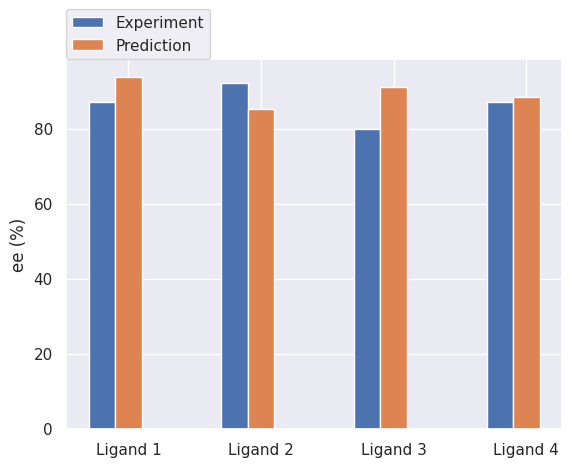

In [16]:
plt.bar(list(range(len(extlig_ee_truth))),extlig_ee_truth,width=0.2,label="Experiment")
plt.bar(np.array(list(range(len(extlig_ee_pred))))+0.2,extlig_ee_pred,width=0.2,label="Prediction")
plt.xticks([0.2,1.2,2.2,3.2],["Ligand 1","Ligand 2","Ligand 3", "Ligand 4"])
plt.legend(loc=(0,1))
plt.ylabel("ee (%)")

In [19]:
extlig_ee_truth,extlig_ee_pred

(array([86.99999992, 92.        , 80.00000072, 87.00000161]),
 array([93.77806639, 85.19819509, 91.0609484 , 88.35349412]))

Text(0, 0.5, 'ee (%)')

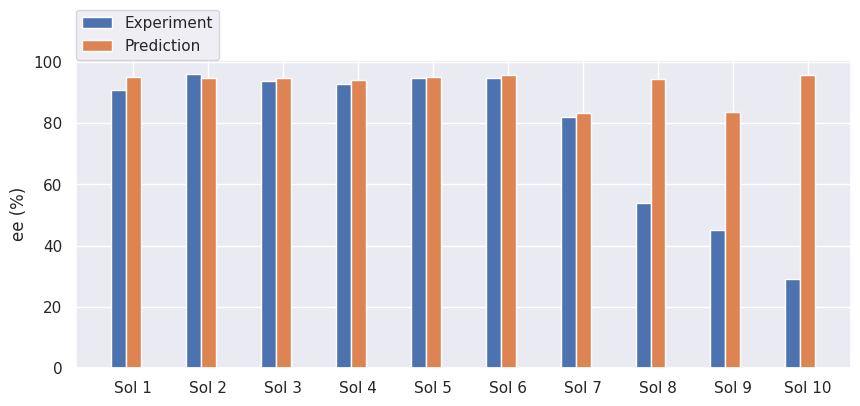

In [17]:
plt.figure(figsize=(10,4))
plt.bar(list(range(len(extsol_ee_truth))),extsol_ee_truth,width=0.2,label="Experiment")
plt.bar(np.array(list(range(len(extsol_ee_pred))))+0.2,extsol_ee_pred,width=0.2,label="Prediction")
plt.xticks([0.2,1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2],["Sol 1","Sol 2","Sol 3", "Sol 4","Sol 5","Sol 6","Sol 7", "Sol 8","Sol 9","Sol 10"])
plt.legend(loc=(0,1))
plt.ylabel("ee (%)")

### Remove training data with ee > 90%, re-train model and perform prediction

In [1]:
import pandas as pd
import numpy as np
import warnings
from copy import deepcopy
from rxnpredict.ts.desc import sel_satisfy_ts_data,vec_ts_pair_in_dataset,get_diff_ts_desc,load_map
from rxnpredict.models.utils import get_model
from rxnpredict.evaluate.eval import get_val_score_add_data,get_predict,get_topk_rxn_comb_df
from rxnpredict.descriptors.desc import vect_columns_in_dataset,sel_high_corr_desc,reduce_desc_with_corr_matrix
from rxnpredict.descriptors.utils import process_desc,maxminscale
from rdkit import RDLogger
from rxnpredict.utils.convert import ddG2ee
from rxnpredict.descriptors.utils import canonical_smiles
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,r2_score
from scipy.stats import pearsonr
import itertools, optuna
from optuna.samplers import TPESampler
from functools import partial
from rxnpredict.models.hyperopt import gb_objective
from sklearn.feature_selection import RFECV
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "GradientBoostingRegressor"
desc_name = "SPOC"
merge_method = "delta"
topk = 300
dist_type = "euclidean"
descriptor_pearsonr_threshold = 0.95
descriptor_target_pearsonr_threshold = 0.2
base_rct_keys = ["Reactant1","Reactant2"]
target_rct_keys = ["Reactant1","Reactant2"]
base_sol_keys = ["Solvents"]
target_sol_keys = ["Solvents"]
base_rgt_keys = ["Reagents"]
target_rgt_keys = ["Reagents"]
base_ts_key = ["Reactant2","Reagent5"]
target_ts_key = ["Reactant2","Reagent2"]
selection_inf = {
            "type": "loo",
            "fold": 10,
            "metric": [
                "r2",
                "mae"
            ]}

In [3]:
n_trials = 15
random_state = 1024

In [4]:
base_data_file = "../data/base_data.csv"
target_data_file = "../data/target_data.csv"
base_data = pd.read_csv(base_data_file)
target_data = pd.read_csv(target_data_file)
base_data_clean = base_data.dropna(axis=1, how='all')
target_data_clean = target_data.dropna(axis=1, how='all')

# fill NaN with empty string
for key in target_rct_keys + target_sol_keys + target_rgt_keys:
    target_data_clean[key] = target_data_clean[key].fillna('')
for key in base_rct_keys + base_sol_keys + base_rgt_keys:
    base_data_clean[key] = base_data_clean[key].fillna('')
## Drop rows with missing target values
target_data_clean = target_data_clean.dropna(subset=target_rct_keys+target_ts_key)
base_data_clean = base_data_clean.dropna(subset=base_rct_keys+base_ts_key)
clear_smiles_tsdesc_map = np.load("../desc/clear_smiles_tsdesc_map.npy",allow_pickle=True).item()
print(f"base data shape: {base_data_clean.shape}", f"target data shape: {target_data_clean.shape}")

base data shape: (466, 16) target data shape: (68, 12)


In [5]:
sel_target_data_clean = target_data_clean.iloc[sel_satisfy_ts_data(target_data_clean,target_ts_key,clear_smiles_tsdesc_map)]
sel_base_data_clean = base_data_clean.iloc[sel_satisfy_ts_data(base_data_clean,base_ts_key,clear_smiles_tsdesc_map)]
print(f"Dataset size: target = {target_data_clean.shape} (without ts constraint) {sel_target_data_clean.shape} (with ts constraint), base = {base_data_clean.shape} (without ts constraint) {sel_base_data_clean.shape} (with ts constraint)")
sel_target_data_clean_low = sel_target_data_clean[sel_target_data_clean['ee']<90]
sel_target_data_clean_high = sel_target_data_clean[sel_target_data_clean['ee']>=90]
low_data_idx_lst = np.where(sel_target_data_clean['ee'].to_numpy()<90)[0]
high_data_idx_lst = np.where(sel_target_data_clean['ee'].to_numpy()>=90)[0]

Dataset size: target = (68, 12) (without ts constraint) (55, 12) (with ts constraint), base = (466, 16) (without ts constraint) (446, 16) (with ts constraint)


In [8]:
high_data_idx_lst

array([ 8, 19, 29, 35, 41])

In [62]:
sel_target_data_clean = target_data_clean.iloc[sel_satisfy_ts_data(target_data_clean,target_ts_key,clear_smiles_tsdesc_map)]
sel_base_data_clean = base_data_clean.iloc[sel_satisfy_ts_data(base_data_clean,base_ts_key,clear_smiles_tsdesc_map)]
print(f"Dataset size: target = {target_data_clean.shape} (without ts constraint) {sel_target_data_clean.shape} (with ts constraint), base = {base_data_clean.shape} (without ts constraint) {sel_base_data_clean.shape} (with ts constraint)")
sel_target_data_clean_low = sel_target_data_clean[sel_target_data_clean['ee']<90]
sel_target_data_clean_high = sel_target_data_clean[sel_target_data_clean['ee']>=90]
low_data_idx_lst = np.where(sel_target_data_clean['ee'].to_numpy()<90)[0]
high_data_idx_lst = np.where(sel_target_data_clean['ee'].to_numpy()>=90)[0]


# perform vectorization for target values with ts descriptors
target_ts_desc_inf = vec_ts_pair_in_dataset(sel_target_data_clean,target_ts_key,clear_smiles_tsdesc_map)
target_ts_desc,target_ts_desc_names = target_ts_desc_inf[:,0,:].astype(np.float32),target_ts_desc_inf[:,1,:]
base_ts_desc_inf = vec_ts_pair_in_dataset(sel_base_data_clean,base_ts_key,clear_smiles_tsdesc_map)
base_ts_desc,base_ts_desc_names = base_ts_desc_inf[:,0,:].astype(np.float32),base_ts_desc_inf[:,1,:]
print(f"target TS descriptor shape: {target_ts_desc.shape}, name shape: {target_ts_desc_names.shape}, base TS descriptor shape: {base_ts_desc.shape}, name shape: {base_ts_desc_names.shape}")


# calculate difference descriptors between R/S TS
target_ts_diff_desc,target_ts_diff_desc_names = get_diff_ts_desc(target_ts_desc,target_ts_desc_names[0])
base_ts_diff_desc,base_ts_diff_desc_names = get_diff_ts_desc(base_ts_desc,base_ts_desc_names[0])
target_ts_desc = np.concatenate([target_ts_desc,target_ts_diff_desc],axis=1)                                             ## full TS descriptors
base_ts_desc = np.concatenate([base_ts_desc,base_ts_diff_desc],axis=1)                                                   ## full TS descriptors
target_ts_desc_names = np.concatenate([target_ts_desc_names[0],target_ts_diff_desc_names],axis=0)                        ## full TS descriptor names
base_ts_desc_names = np.concatenate([base_ts_desc_names[0],base_ts_diff_desc_names],axis=0)                              ## full TS descriptor names
target_ddG = sel_target_data_clean["ddG"].to_numpy()
base_ddG = sel_base_data_clean["ddG"].to_numpy()
print(f"Full target TS descriptor shape: {target_ts_desc.shape}, name shape: {target_ts_desc_names.shape}, base TS descriptor shape: {base_ts_desc.shape}, name shape: {base_ts_desc_names.shape}")

Dataset size: target = (68, 12) (without ts constraint) (55, 12) (with ts constraint), base = (466, 16) (without ts constraint) (446, 16) (with ts constraint)
target TS descriptor shape: (55, 114), name shape: (55, 114), base TS descriptor shape: (446, 114), name shape: (446, 114)
Full target TS descriptor shape: (55, 171), name shape: (171,), base TS descriptor shape: (446, 171), name shape: (171,)


In [63]:
pregen_desc_map = np.load("../desc/desc_for_other_components.npy",allow_pickle=True).item()

# descriptor process
concat_ts_desc,concat_ts_desc_process_ret_idx = process_desc(np.concatenate([target_ts_desc,base_ts_desc],axis=0),return_idx=True)                                                                              # descriptor process
concat_ts_desc,concat_ts_desc_max,concat_ts_desc_min = maxminscale(concat_ts_desc,return_scale=True)                                                                                                            # descriptor process
# remove correlated descriptors
concat_ts_desc,concat_ts_desc_high_tgt_corr_idx = sel_high_corr_desc(concat_ts_desc,np.concatenate([target_ddG,base_ddG]),threshold=descriptor_target_pearsonr_threshold,return_idx=True)                       # descriptor elimination
concat_ts_desc,concat_ts_desc_high_corr_idx = reduce_desc_with_corr_matrix(concat_ts_desc,threshold=descriptor_pearsonr_threshold,ret_idx=True)                                                                 # descriptor elimination

target_ts_desc_ = concat_ts_desc[:target_ts_desc.shape[0]]
base_ts_desc_ = concat_ts_desc[target_ts_desc.shape[0]:]
print(f"target_ts_desc shape: {target_ts_desc.shape}, base_ts_desc shape: {base_ts_desc.shape}")
print(f"target_ts_desc_ shape: {target_ts_desc_.shape},  base_ts_desc_ shape: {base_ts_desc_.shape}")


target_merg_rxn_desc = pregen_desc_map[desc_name]["target"]
base_merg_rxn_desc = pregen_desc_map[desc_name]["base"]
concat_merge_rxn_desc, concat_merge_rxn_desc_process_ret_idx = process_desc(np.concatenate([target_merg_rxn_desc,base_merg_rxn_desc],axis=0),return_idx=True)                                                               # descriptor process
concat_merge_rxn_desc,concat_merge_rxn_desc_max,concat_merge_rxn_desc_min = maxminscale(concat_merge_rxn_desc,return_scale=True)                                                                                            # descriptor process
concat_merge_rxn_desc,concat_merge_rxn_desc_high_tgt_corr_idx = sel_high_corr_desc(concat_merge_rxn_desc,np.concatenate([target_ddG,base_ddG]),threshold=descriptor_target_pearsonr_threshold,return_idx=True)              # descriptor elimination
concat_merge_rxn_desc,concat_merge_rxn_desc_high_corr_idx = reduce_desc_with_corr_matrix(concat_merge_rxn_desc,threshold=descriptor_pearsonr_threshold,ret_idx=True)                                                        # descriptor process

target_merg_rxn_desc_ = concat_merge_rxn_desc[:target_merg_rxn_desc.shape[0]]
base_merg_rxn_desc_ = concat_merge_rxn_desc[target_merg_rxn_desc.shape[0]:]
print(f"{desc_name} target_merg_rxn_desc shape: {target_merg_rxn_desc.shape}, base_merg_rxn_desc shape: {base_merg_rxn_desc.shape}")
print(f"{desc_name} target_merg_rxn_desc_ shape: {target_merg_rxn_desc_.shape},  base_merg_rxn_desc_ shape: {base_merg_rxn_desc_.shape}")

target_full_rxn_desc = np.concatenate([target_merg_rxn_desc_,target_ts_desc_],axis=1)                       # TS + other component descriptors
base_full_rxn_desc = np.concatenate([base_merg_rxn_desc_,base_ts_desc_],axis=1)                             # TS + other component descriptors

full_rxn_desc_std, full_rxn_desc_process_ret_idx = process_desc(np.concatenate([target_full_rxn_desc,base_full_rxn_desc],axis=0),return_idx=True)
full_rxn_desc_std, full_rxn_desc_max, full_rxn_desc_min = maxminscale(full_rxn_desc_std,return_scale=True)

target_full_rxn_desc_ = full_rxn_desc_std[:target_full_rxn_desc.shape[0]]
base_full_rxn_desc_ = full_rxn_desc_std[target_full_rxn_desc.shape[0]:]

target_ts_desc shape: (55, 171), base_ts_desc shape: (446, 171)
target_ts_desc_ shape: (55, 67),  base_ts_desc_ shape: (446, 67)
SPOC target_merg_rxn_desc shape: (55, 9032), base_merg_rxn_desc shape: (446, 9032)
SPOC target_merg_rxn_desc_ shape: (55, 193),  base_merg_rxn_desc_ shape: (446, 193)


In [45]:
model = GradientBoostingRegressor(n_estimators=117, min_samples_split=5, max_depth=3, random_state=1024)
dropped_feat_idx_lst = [0, 53, 1, 42, 5, 2, 21, 172]
remained_feat_idx_lst = [i for i in range(base_full_rxn_desc_.shape[1]) if i not in dropped_feat_idx_lst]
va_Y,va_P,score_map = get_val_score_add_data(model,base_full_rxn_desc_[:,remained_feat_idx_lst],base_ddG,
                                             target_full_rxn_desc_[:,remained_feat_idx_lst],target_ddG,
                                             selection_inf=selection_inf,merge_method=merge_method,topk=topk,dist_type=dist_type)
print(f"score map: {score_map}")

Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300
score map: {'r2': 0.7813588887800107, 'mae': 0.16055078585490806}


In [64]:
tgt_lig_lst = sel_target_data_clean["Reagent2"].to_list()
tgt_rgt_lst = sel_target_data_clean["Reagents"].to_list()
tgt_rgt1_lst = sorted(list(set(sel_target_data_clean["Reagent1"].to_list())))
tgt_rgt2_lst = sorted(list(set(sel_target_data_clean["Reagent3"].to_list())))
tgt_rgt3_lst = sorted(list(set(sel_target_data_clean["Reagent4"].to_list())))
tgt_sol_lst = sel_target_data_clean["Solvents"].to_list()
proposed_lig_smi_set = pd.read_csv("../data/proposed_ligand_library.csv")["SMILES"].to_list()
lig_lst = [item.split(",")[1] for item in list(load_map("../data/smi_idx_map.csv").keys())]
rgt_set = sorted([canonical_smiles(".".join([rgt1,rgt2,rgt3])) for rgt1,rgt2,rgt3 in itertools.product(tgt_rgt1_lst,tgt_rgt2_lst,tgt_rgt3_lst)])

lig_set = sorted(list(set(sel_target_data_clean["Reagent2"].to_list() + sel_base_data_clean["Reagent5"].to_list() + proposed_lig_smi_set + lig_lst)))
sol_set = sorted(list(set(tgt_sol_lst)))
print(f"ligand count: {len(lig_set)}, reagent count: {len(rgt_set)}")
tot_comb = list(itertools.product(lig_set,rgt_set,sol_set))
tot_comb = [(item[0],canonical_smiles(f"{item[0]}.{item[1]}"),item[2]) for item in tot_comb]

low_tgt_lig_lst = sel_target_data_clean_low['Reagent2'].to_list()
low_tgt_rgt_lst = sel_target_data_clean_low["Reagents"].to_list()
low_tgt_sol_lst = sel_target_data_clean_low["Solvents"].to_list()


existed_comb = [(lig,rgt,sol) for lig,rgt,sol in zip(low_tgt_lig_lst,low_tgt_rgt_lst,low_tgt_sol_lst)]
ret_comb = [comb for comb in tot_comb if comb not in existed_comb]
print(f"Total combinations: {len(tot_comb)}, existed combinations: {len(existed_comb)}, new combinations: {len(ret_comb)}")

vir_comb = ret_comb
ret_vir_comb_df = pd.DataFrame({"Reactant1": [sel_target_data_clean["Reactant1"][0]] * len(vir_comb),
                            "Reactant2": [sel_target_data_clean["Reactant2"][0]] * len(vir_comb),
                            "Ligand": [lig for lig,rgt,sol in vir_comb],
                            "Reagents": [rgt for lig,rgt,sol in vir_comb],  
                            "Solvents": [sol for lig,rgt,sol in vir_comb]})
sel_vir_idx = sel_satisfy_ts_data(ret_vir_comb_df,["Reactant2","Ligand"],clear_smiles_tsdesc_map,verbose=False)
miss_vir_idx = list(set(range(0,ret_vir_comb_df.shape[0])) - set(sel_vir_idx))
sel_vir_comb_df = ret_vir_comb_df.iloc[sel_vir_idx,:]
miss_vir_comb_df = ret_vir_comb_df.iloc[miss_vir_idx,:]
print(f"Size of selected virtual combinations: {sel_vir_comb_df.shape[0]}")
print(f"Size of missing virtual combinations: {miss_vir_comb_df.shape[0]}")

ligand count: 85, reagent count: 6
Total combinations: 510, existed combinations: 50, new combinations: 460
Size of selected virtual combinations: 436
Size of missing virtual combinations: 24


In [47]:
# descriptor for other components
vir_merg_rct_desc,_,_ = vect_columns_in_dataset(sel_vir_comb_df,["Reactant1","Reactant2"],{'descriptor':desc_name},verbose=True)
vir_merg_sol_desc,_,_ = vect_columns_in_dataset(sel_vir_comb_df,["Solvents"],{'descriptor':desc_name},verbose=True)
vir_merg_reag_desc,_,_ = vect_columns_in_dataset(sel_vir_comb_df,["Reagents"],{'descriptor':desc_name},verbose=True)

vir_merg_rxn_desc = np.concatenate([vir_merg_rct_desc,vir_merg_sol_desc,vir_merg_reag_desc],axis=1)
# descriptor for TS
vir_ts_desc_inf = vec_ts_pair_in_dataset(sel_vir_comb_df,["Reactant2","Ligand"],clear_smiles_tsdesc_map)
vir_ts_desc,vir_ts_desc_names = vir_ts_desc_inf[:,0,:].astype(np.float32),vir_ts_desc_inf[:,1,:]

# calculate difference descriptors between R/S TS
vir_ts_diff_desc,vir_ts_diff_desc_names = get_diff_ts_desc(vir_ts_desc,vir_ts_desc_names[0])
vir_ts_desc = np.concatenate([vir_ts_desc,vir_ts_diff_desc],axis=1)                                             ## full TS descriptors

vir_ts_desc_ = ((vir_ts_desc[:,concat_ts_desc_process_ret_idx]-concat_ts_desc_min) / (concat_ts_desc_max-concat_ts_desc_min))[:,concat_ts_desc_high_tgt_corr_idx][:,concat_ts_desc_high_corr_idx]     
#vir_merg_rxn_desc_ = 
vir_merg_rxn_desc_ = ((vir_merg_rxn_desc[:,concat_merge_rxn_desc_process_ret_idx]-concat_merge_rxn_desc_min) / (concat_merge_rxn_desc_max-concat_merge_rxn_desc_min))[:,concat_merge_rxn_desc_high_tgt_corr_idx][:,concat_merge_rxn_desc_high_corr_idx]
vir_full_rxn_desc = (np.concatenate([vir_merg_rxn_desc_,vir_ts_desc_],axis=1)[:,full_rxn_desc_process_ret_idx] - full_rxn_desc_min) / (full_rxn_desc_max-full_rxn_desc_min)  ## final descriptor
print(vir_full_rxn_desc.max(axis=0).max(),vir_full_rxn_desc.min(axis=0).min())

4.0 -0.6956223249435425


In [55]:
vir_P = get_predict(model,base_full_rxn_desc_[:,remained_feat_idx_lst],base_ddG,
                    target_full_rxn_desc_[low_data_idx_lst][:,remained_feat_idx_lst],target_ddG[low_data_idx_lst],
                    vir_full_rxn_desc[:,remained_feat_idx_lst],merge_method=merge_method,simi_eval=True,
                    dist_type=dist_type,topk=topk,base_simi_X=None,dest_simi_X=None,verbose=True)
vir_ee = ddG2ee(vir_P,60+273.15)
sel_vir_comb_df["Predict_ddG"] = vir_P
sel_vir_comb_df["Predict_ee"] = vir_ee
topk_recommend_res = get_topk_rxn_comb_df(sel_vir_comb_df,"Predict_ddG",topk=10)
topk_rgts = topk_recommend_res["Reagents"].to_list()
topk_ddG = topk_recommend_res["Predict_ddG"].to_numpy()
topk_ee = ddG2ee(topk_ddG,60+273.15)

Evalutaion process: merge method delta, similarity evaluation True, distance type euclidean, topk 300
326 times model fitting


In [57]:
topk_recommend_res.to_csv("./results/top10_recommend_reacton_without_high_ee.csv")